In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
DATA_DIR = os.path.expanduser("~/gcs-data/Full_data")
os.listdir(DATA_DIR)

['2020_cleaned.csv',
 'country_continent_map.csv',
 'epicov_2020_200k.csv',
 'epicov_2021_200k.csv',
 'epicov_2023_200k.parquet',
 'epicov_2025_200k.parquet',
 'models']

In [3]:
df20 = pd.read_csv(os.path.join(DATA_DIR, "epicov_2020_200k.csv"))
df21 = pd.read_csv(os.path.join(DATA_DIR, "epicov_2021_200k.csv"))
df23 = pd.read_parquet(os.path.join(DATA_DIR, "epicov_2023_200k.parquet"))
df25 = pd.read_parquet(os.path.join(DATA_DIR, "epicov_2025_200k.parquet"))
df20.shape, df21.shape, df23.shape, df25.shape

/tmp/ipykernel_5188/1650611895.py:1: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  df20 = pd.read_csv(os.path.join(DATA_DIR, "epicov_2020_200k.csv"))


((200524, 18), (213997, 18), (203488, 18), (177116, 18))

In [4]:
set(df20.columns) == set(df21.columns) == set(df23.columns) == set(df25.columns)

True

In [5]:
def add_columns(df):
    df.rename(columns={"Accession ID": "accession_id", "Collection date": "collection_date", "Submission date": "submission_date"}, inplace=True)
    # 'mixed' allows pandas to infer formats row-by-row
    df["collection_date"] = pd.to_datetime(df["collection_date"], format='mixed')
    df["submission_date"] = pd.to_datetime(df["submission_date"], format='mixed')
    df["collection_yr"] = df["collection_date"].dt.year
    df["submission_yr"] = df["submission_date"].dt.year
    # Extract Day of Year (1-365) to align Jan 2020 with Jan 2022
    df['collection_doy'] = df['collection_date'].dt.dayofyear
    df['submission_doy'] = df['submission_date'].dt.dayofyear
    return df

In [6]:
df20 = add_columns(df20)
df21 = add_columns(df21)
df23 = add_columns(df23)
df25 = add_columns(df25)

In [7]:
df20.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200524 entries, 0 to 200523
Data columns (total 22 columns):
 #   Column                           Non-Null Count   Dtype         
---  ------                           --------------   -----         
 0   accession_id                     200524 non-null  object        
 1   submission_date                  200524 non-null  datetime64[ns]
 2   Virus name                       200524 non-null  object        
 3   collection_date                  200524 non-null  datetime64[ns]
 4   Location                         200524 non-null  object        
 5   Host                             200524 non-null  object        
 6   Additional location information  6210 non-null    object        
 7   Sampling strategy                11252 non-null   object        
 8   Gender                           200524 non-null  object        
 9   Patient age                      200519 non-null  object        
 10  Patient status                   200509 non-

In [8]:
def get_abs_cumm_counts(df, date_col, year_col='collection_yr'):
    abs_counts = df.groupby(date_col).size().reset_index(name='abs_count')
    abs_counts['cumm_count'] = abs_counts['abs_count'].cumsum()
    abs_counts[year_col] = df[year_col].iloc[0]
    return abs_counts

In [9]:
# Collect number of sequences submitted each day
coll_20 = get_abs_cumm_counts(df20, 'collection_doy')
coll_21 = get_abs_cumm_counts(df21, 'collection_doy')
coll_23 = get_abs_cumm_counts(df23, 'collection_doy')
coll_25 = get_abs_cumm_counts(df25, 'collection_doy')
coll_20.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 186 entries, 0 to 185
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   collection_doy  186 non-null    int32
 1   abs_count       186 non-null    int64
 2   cumm_count      186 non-null    int64
 3   collection_yr   186 non-null    int32
dtypes: int32(2), int64(2)
memory usage: 4.5 KB


In [10]:
cols = ["accession_id", "collection_date", "submission_date", "collection_yr", "submission_yr", "collection_doy", "submission_doy"]
df1 = pd.concat([df20[cols], df21[cols], df23[cols], df25[cols]], ignore_index=True)
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 795125 entries, 0 to 795124
Data columns (total 7 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   accession_id     795125 non-null  object        
 1   collection_date  795125 non-null  datetime64[ns]
 2   submission_date  795125 non-null  datetime64[ns]
 3   collection_yr    795125 non-null  int32         
 4   submission_yr    795125 non-null  int32         
 5   collection_doy   795125 non-null  int32         
 6   submission_doy   795125 non-null  int32         
dtypes: datetime64[ns](2), int32(4), object(1)
memory usage: 30.3+ MB


In [11]:
coll_df = pd.concat([coll_20, coll_21, coll_23, coll_25], axis=0)
coll_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 557 entries, 0 to 321
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   collection_doy  557 non-null    int32
 1   abs_count       557 non-null    int64
 2   cumm_count      557 non-null    int64
 3   collection_yr   557 non-null    int32
dtypes: int32(2), int64(2)
memory usage: 17.4 KB


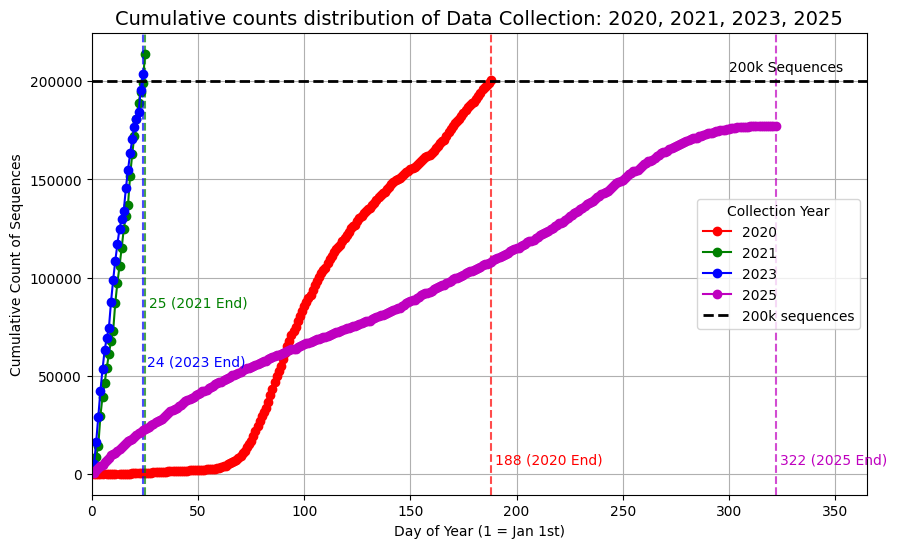

In [12]:
# 3. Plotting
plt.figure(figsize=(10, 6))

# Option A: Density Plot (The "Spike" vs "Hill")
# 'common_norm=False' allows each year to be normalized to its own volume, 
# showing the shape clearly regardless of total count differences.
# sns.catplot(data=coll_df, x='collection_doy', y='cumm_count', hue='collection_yr', palette='viridis', kind='bar', height=6, aspect=1.5)
plt.plot(coll_20['collection_doy'], coll_20['cumm_count'], color='r', marker='o', label='2020')
plt.axvline(coll_20['collection_doy'].max() , color='r', alpha=0.7, linewidth=1.5, linestyle='--')
plt.plot(coll_21['collection_doy'], coll_21['cumm_count'], color='g', marker='o', label='2021')
plt.axvline(coll_21['collection_doy'].max() , color='g', alpha=0.7, linewidth=1.5, linestyle='--')
plt.plot(coll_23['collection_doy'], coll_23['cumm_count'], color='b', marker='o', label='2023')
plt.axvline(coll_23['collection_doy'].max() , color='b', alpha=0.7, linewidth=1.5, linestyle='--')
plt.plot(coll_25['collection_doy'], coll_25['cumm_count'], color='m', marker='o', label='2025')
plt.axvline(coll_25['collection_doy'].max() , color='m', alpha=0.7, linewidth=1.5, linestyle='--')
plt.axhline(2e5 , color='black', linewidth=2, linestyle='--', label='200k sequences')
plt.legend(title='Collection Year')

# Annotate vlines and hline
plt.text(coll_20['collection_doy'].max()+2, 5000, f'{coll_20["collection_doy"].max()} (2020 End)', color='r')
plt.text(coll_21['collection_doy'].max()+2, 85000, f'{coll_21["collection_doy"].max()} (2021 End)', color='g')
plt.text(coll_23['collection_doy'].max()+2, 55000, f'{coll_23["collection_doy"].max()} (2023 End)', color='b')
plt.text(coll_25['collection_doy'].max()+2, 5000, f'{coll_25["collection_doy"].max()} (2025 End)', color='m')
plt.text(300, 2e5 + 5000, '200k Sequences', color='black')

plt.title("Cumulative counts distribution of Data Collection: 2020, 2021, 2023, 2025", fontsize=14)
plt.xlabel("Day of Year (1 = Jan 1st)")
plt.ylabel("Cumulative Count of Sequences")
plt.xlim(0, 365) # Lock to a full year view
plt.grid(True)
plt.show()

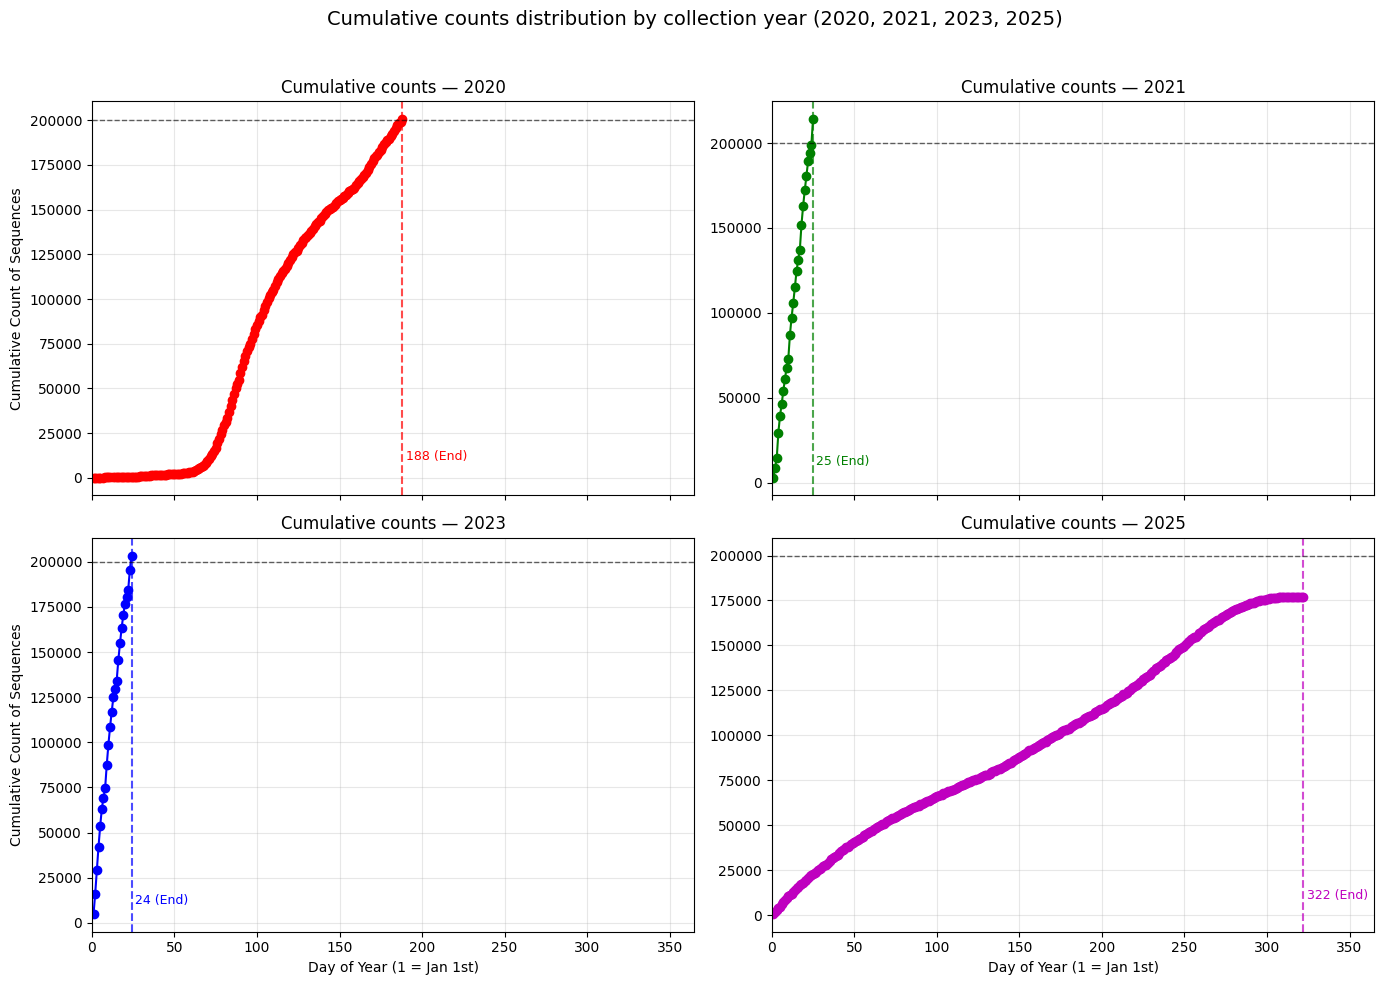

In [13]:
# 3. Plotting — one subplot per year
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)
axes = axes.ravel()

datasets = [
    (coll_20, "2020", "r"),
    (coll_21, "2021", "g"),
    (coll_23, "2023", "b"),
    (coll_25, "2025", "m"),
]

for ax, (df, year, color) in zip(axes, datasets):
    ax.plot(df["collection_doy"], df["cumm_count"], color=color, marker="o", label=year)
    ax.axvline(df["collection_doy"].max(), color=color, alpha=0.7, linewidth=1.5, linestyle="--")
    ax.axhline(2e5, color="black", linewidth=1, linestyle="--", alpha=0.6)
    ax.set_title(f"Cumulative counts — {year}")
    ax.set_xlim(0, 365)
    ax.grid(True, alpha=0.3)
    xpos = df["collection_doy"].max() + 2
    ypos = max(df["cumm_count"].max() * 0.05, 1)
    ax.text(xpos, ypos, f"{df['collection_doy'].max()} (End)", color=color, fontsize=9)

# Axis labels
for a in axes[[2, 3]]:
    a.set_xlabel("Day of Year (1 = Jan 1st)")
for a in axes[[0, 2]]:
    a.set_ylabel("Cumulative Count of Sequences")

fig.suptitle("Cumulative counts distribution by collection year (2020, 2021, 2023, 2025)", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

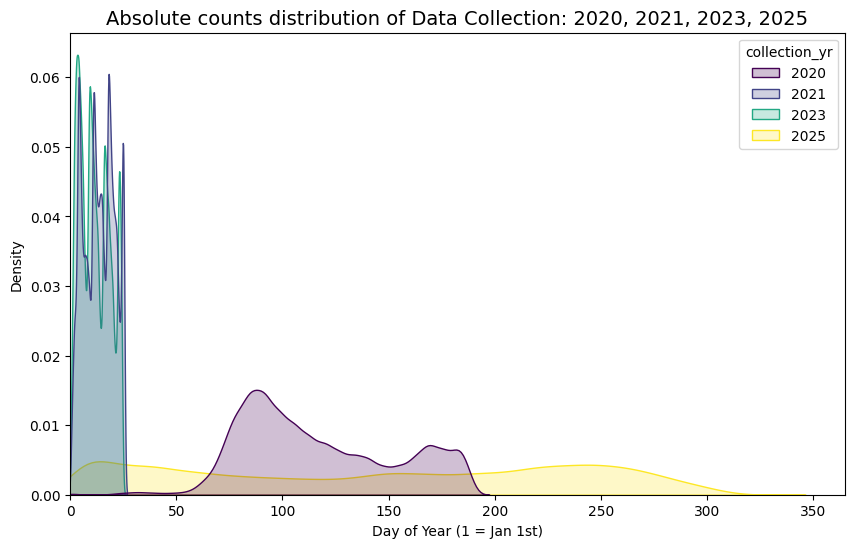

In [16]:
# 3. Plotting
plt.figure(figsize=(10, 6))

# Option A: Density Plot (The "Spike" vs "Hill")
# 'common_norm=False' allows each year to be normalized to its own volume, 
# showing the shape clearly regardless of total count differences.
sns.kdeplot(data=df1, x='collection_doy', hue='collection_yr', fill=True, common_norm=False, palette='viridis')

plt.title("Absolute counts distribution of Data Collection: 2020, 2021, 2023, 2025", fontsize=14)
plt.xlabel("Day of Year (1 = Jan 1st)")
plt.xlim(0, 365) # Lock to a full year view
plt.show()

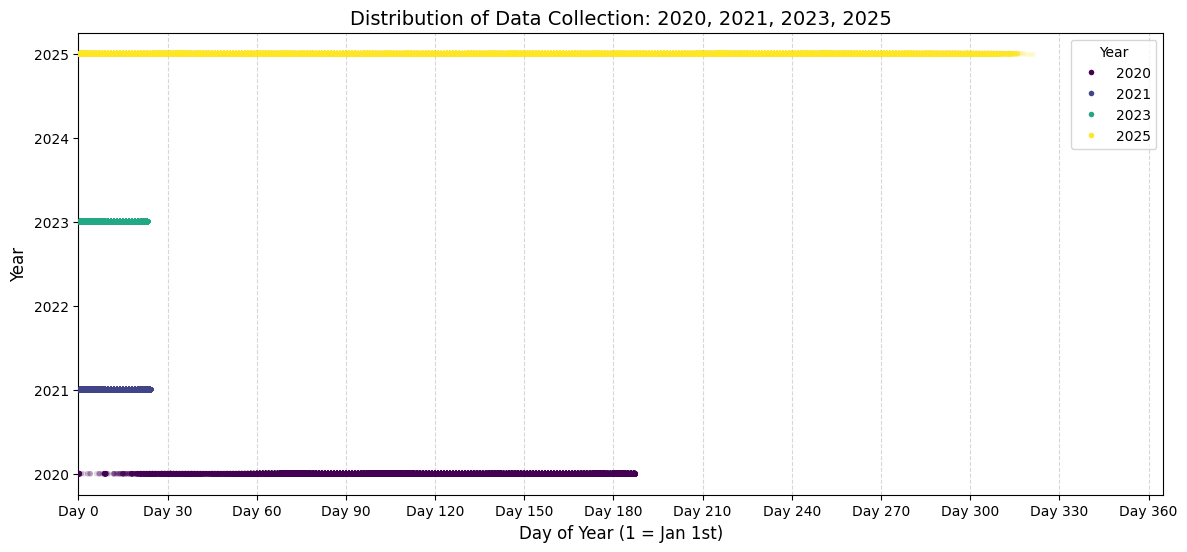

In [17]:
plt.figure(figsize=(14, 6))

# 3. Create Strip Plot
    # TIP: We use .sample(frac=0.1) to plot only 10% of data for speed/clarity. 
    # If you want all data, remove .sample() but lower 'alpha' and 'size'.
ax = sns.stripplot(
    # data=df.sample(frac=0.1, random_state=42),
    data=df1,  
    x='collection_doy', 
    y='collection_yr',           # Categorical Y-axis separates the years
    hue='collection_yr',         # Colors them differently
    jitter=0.25,        # Adds random vertical noise so dots don't overlap perfectly
    size=4,             # Keep dots small
    alpha=0.15,          # High transparency to show density (darker = more data)
    palette='viridis'
)

# plt.title("Timeline of Data Collection by Year (Strip Plot)", fontsize=14)
plt.title("Distribution of Data Collection: 2020, 2021, 2023, 2025", fontsize=14)
plt.xlabel("Day of Year (1 = Jan 1st)", fontsize=12)
plt.ylabel("Year", fontsize=12)
plt.xlim(0, 365)  # Lock axis to full year
plt.grid(True, axis='x', linestyle='--', alpha=0.5)

plt.xticks(ticks=np.arange(0, 366, 30), labels=[f"Day {i}" for i in np.arange(0, 366, 30)])
plt.legend(title='Year', loc='upper right')

legend = ax.get_legend()

# Loop through the legend handles (markers) and make them opaque
if legend:
    for handle in legend.legend_handles:
        handle.set_alpha(1.0)  # 1.0 = Fully Opaque

plt.show()

In [22]:
def get_submission_yr(df, year=2020):
    df_sub = df[df['submission_yr'] == year]
    return get_abs_cumm_counts(df_sub, 'submission_doy', 'submission_yr')

In [23]:
sub_20 = get_submission_yr(df1, 2020)
sub_21 = get_submission_yr(df1, 2021)
sub_22 = get_submission_yr(df1, 2022)
sub_23 = get_submission_yr(df1, 2023)
sub_24 = get_submission_yr(df1, 2024)
sub_25 = get_submission_yr(df1, 2025)

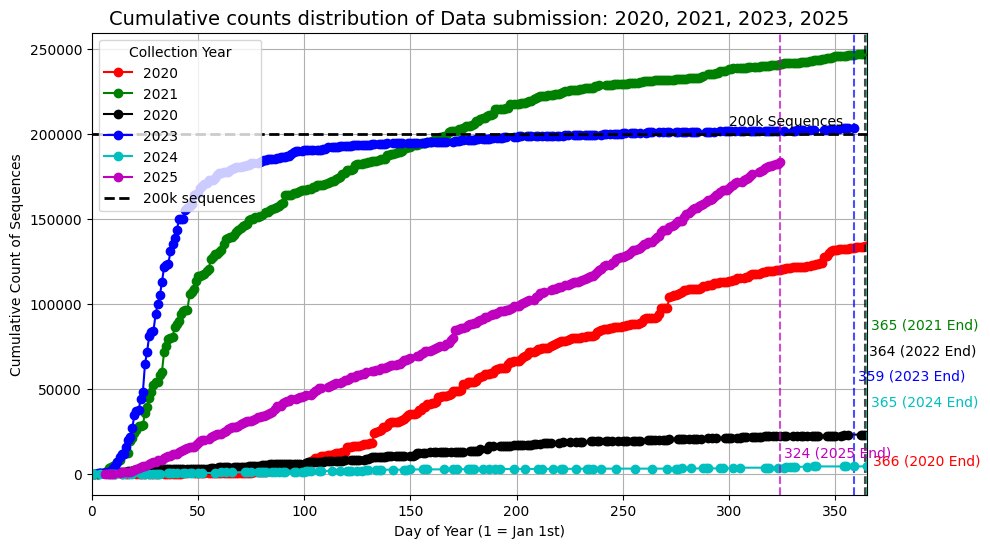

In [25]:
# 3. Plotting
plt.figure(figsize=(10, 6))

# Option A: Density Plot (The "Spike" vs "Hill")
# 'common_norm=False' allows each year to be normalized to its own volume, 
# showing the shape clearly regardless of total count differences.
# sns.catplot(data=coll_df, x='collection_doy', y='cumm_count', hue='collection_yr', palette='viridis', kind='bar', height=6, aspect=1.5)
plt.plot(sub_20['submission_doy'], sub_20['cumm_count'], color='r', marker='o', label='2020')
plt.axvline(sub_20['submission_doy'].max() , color='r', alpha=0.7, linewidth=1.5, linestyle='--')
plt.plot(sub_21['submission_doy'], sub_21['cumm_count'], color='g', marker='o', label='2021')
plt.axvline(sub_21['submission_doy'].max() , color='g', alpha=0.7, linewidth=1.5, linestyle='--')
plt.plot(sub_22['submission_doy'], sub_22['cumm_count'], color='k', marker='o', label='2020')
plt.axvline(sub_22['submission_doy'].max() , color='k', alpha=0.7, linewidth=1.5, linestyle='--')
plt.plot(sub_23['submission_doy'], sub_23['cumm_count'], color='b', marker='o', label='2023')
plt.axvline(sub_23['submission_doy'].max() , color='b', alpha=0.7, linewidth=1.5, linestyle='--')
plt.plot(sub_24['submission_doy'], sub_24['cumm_count'], color='c', marker='o', label='2024')
plt.axvline(sub_24['submission_doy'].max() , color='c', alpha=0.7, linewidth=1.5, linestyle='--')
plt.plot(sub_25['submission_doy'], sub_25['cumm_count'], color='m', marker='o', label='2025')
plt.axvline(sub_25['submission_doy'].max() , color='m', alpha=0.7, linewidth=1.5, linestyle='--')
plt.axhline(2e5 , color='black', linewidth=2, linestyle='--', label='200k sequences')
plt.legend(title='Collection Year')

# Annotate vlines and hline
plt.text(sub_20['submission_doy'].max()+2, 5000, f'{sub_20["submission_doy"].max()} (2020 End)', color='r')
plt.text(sub_21['submission_doy'].max()+2, 85000, f'{sub_21["submission_doy"].max()} (2021 End)', color='g')
plt.text(sub_22['submission_doy'].max()+2, 70000, f'{sub_22["submission_doy"].max()} (2022 End)', color='k')
plt.text(sub_23['submission_doy'].max()+2, 55000, f'{sub_23["submission_doy"].max()} (2023 End)', color='b')
plt.text(sub_24['submission_doy'].max()+2, 40000, f'{sub_24["submission_doy"].max()} (2024 End)', color='c')
plt.text(sub_25['submission_doy'].max()+2, 10000, f'{sub_25["submission_doy"].max()} (2025 End)', color='m')
plt.text(300, 2e5 + 5000, '200k Sequences', color='black')

plt.title("Cumulative counts distribution of Data submission: 2020, 2021, 2023, 2025", fontsize=14)
plt.xlabel("Day of Year (1 = Jan 1st)")
plt.ylabel("Cumulative Count of Sequences")
plt.xlim(0, 365) # Lock to a full year view
plt.grid(True)
plt.show()

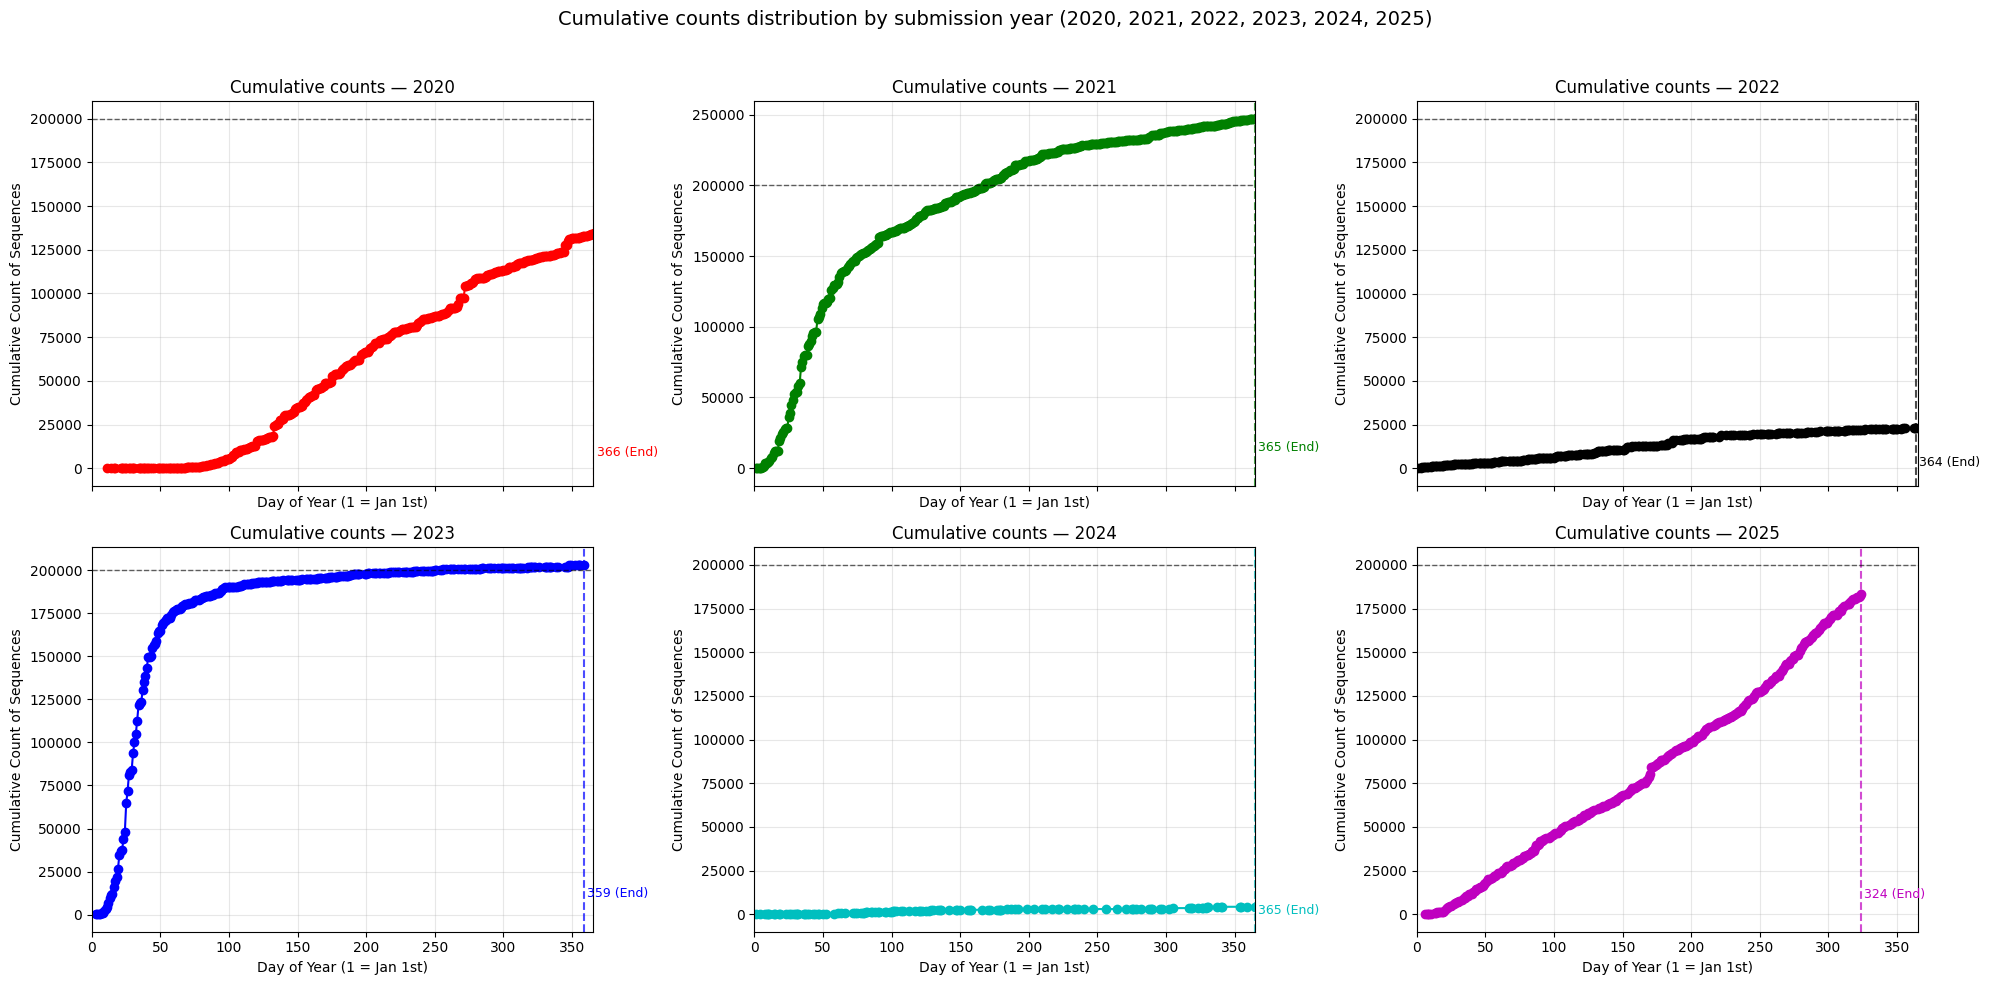

In [30]:
# 3. Plotting — one subplot per year
fig, axes = plt.subplots(2, 3, figsize=(20, 10), sharex=True)
axes = axes.ravel()

datasets = [
    (sub_20, "2020", "r"),
    (sub_21, "2021", "g"),
    (sub_22, "2022", "k"),
    (sub_23, "2023", "b"),
    (sub_24, "2024", "c"),
    (sub_25, "2025", "m"),
]

for ax, (df, year, color) in zip(axes, datasets):
    ax.plot(df["submission_doy"], df["cumm_count"], color=color, marker="o", label=year)
    ax.axvline(df["submission_doy"].max(), color=color, alpha=0.7, linewidth=1.5, linestyle="--")
    ax.axhline(2e5, color="black", linewidth=1, linestyle="--", alpha=0.6)
    ax.set_title(f"Cumulative counts — {year}")
    ax.set_xlim(0, 365)
    ax.grid(True, alpha=0.3)
    xpos = df["submission_doy"].max() + 2
    ypos = max(df["cumm_count"].max() * 0.05, 1)
    ax.text(xpos, ypos, f"{df['submission_doy'].max()} (End)", color=color, fontsize=9)

# Axis labels
for a in axes:
    a.set_xlabel("Day of Year (1 = Jan 1st)")
for a in axes:
    a.set_ylabel("Cumulative Count of Sequences")

fig.suptitle("Cumulative counts distribution by submission year (2020, 2021, 2022, 2023, 2024, 2025)", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

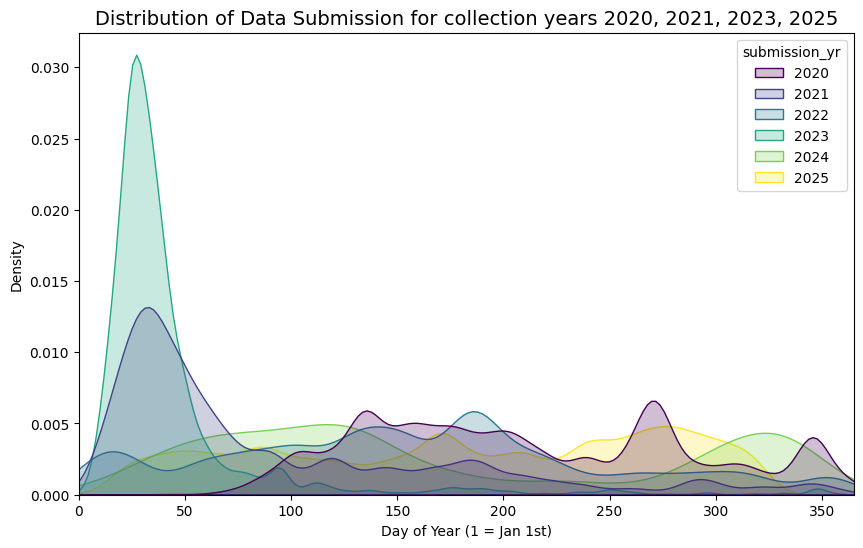

In [20]:
# 3. Plotting
plt.figure(figsize=(10, 6))

# Option A: Density Plot (The "Spike" vs "Hill")
# 'common_norm=False' allows each year to be normalized to its own volume, 
# showing the shape clearly regardless of total count differences.
sns.kdeplot(data=df1, x='submission_doy', hue='submission_yr', fill=True, common_norm=False, palette='viridis')

plt.title("Distribution of Data Submission for collection years 2020, 2021, 2023, 2025", fontsize=14)
plt.xlabel("Day of Year (1 = Jan 1st)")
plt.xlim(0, 365) # Lock to a full year view
plt.show()

In [ ]:
plt.figure(figsize=(14, 6))

# 3. Create Strip Plot
    # TIP: We use .sample(frac=0.1) to plot only 10% of data for speed/clarity. 
    # If you want all data, remove .sample() but lower 'alpha' and 'size'.
ax = sns.stripplot(
    # data=df.sample(frac=0.1, random_state=42),
    data=df,  
    x='submission_doy', 
    y='submission_yr',           # Categorical Y-axis separates the years
    hue='submission_yr',         # Colors them differently
    jitter=0.25,        # Adds random vertical noise so dots don't overlap perfectly
    size=4,             # Keep dots small
    alpha=0.15,          # High transparency to show density (darker = more data)
    palette='viridis'
)

# plt.title("Timeline of Data Collection by Year (Strip Plot)", fontsize=14)
plt.title("Distribution of Data Submission for collection years 2020, 2021, 2023, 2025", fontsize=14)
plt.xlabel("Day of Year (1 = Jan 1st)", fontsize=12)
plt.ylabel("Year", fontsize=12)
plt.xlim(0, 365)  # Lock axis to full year
plt.grid(True, axis='x', linestyle='--', alpha=0.5)

plt.xticks(ticks=np.arange(0, 366, 30), labels=[f"Day {i}" for i in np.arange(0, 366, 30)])
plt.legend(title='Year', loc='upper right')

legend = ax.get_legend()

# Loop through the legend handles (markers) and make them opaque
if legend:
    for handle in legend.legend_handles:
        handle.set_alpha(1.0)  # 1.0 = Fully Opaque

plt.show()

In [ ]:
from countryinfo import CountryInfo

def get_language_codes(country_name):
    try:
        # CountryInfo is smart enough to handle many common aliases
        # e.g., "USA", "UK", "Democratic Republic of Congo"
        country = CountryInfo(country_name)
        
        # .languages() returns a list of ISO 639-1 (2-letter) codes
        codes = country.languages()
        
        if codes:
            return codes
        else:
            return "No language data found."
            
    except KeyError:
        return "Country name not recognized. Try a different variation."

# --- Examples ---
print(f"USA: {get_language_codes('USA')}")
print(f"Congo (Republic): {get_language_codes('Republic of Congo')}")
print(f"Congo (DRC): {get_language_codes('Democratic Republic of the Congo')}")
print(f"Japan: {get_language_codes('Japan')}")

In [ ]:
# Vectorized split and strip (much faster than iterrows)
parts = df["Location"].astype(str).str.split("/", n=3, expand=True)
parts = parts.rename(columns={0: "continent", 1: "country", 2: "state", 3: "city"})
# strip whitespace and replace empty strings with NaN
for c in parts.columns:
    parts[c] = parts[c].where(parts[c].notna(), np.nan).astype(object)
    parts[c] = parts[c].str.strip().replace({"": np.nan})

# Assign new location columns directly (avoid relying on `cols` variable)
df[["continent", "country", "state", "city"]] = parts[["continent", "country", "state", "city"]]
df.drop(columns=["Location"], inplace=True)
df.info()

In [ ]:
df["Patient status"].nunique(), df["Patient status"].value_counts()

In [ ]:
unknown_vals = df[df["Patient status"].astype(str).str.lower().str.startswith("u")]["Patient status"].unique().tolist()
mask = df["Patient status"].isin(unknown_vals)
df.loc[mask, "Patient status"] = "unknown"
df["Patient status"].fillna("unknown", inplace=True)
df["Patient status"].nunique(), df["Patient status"].value_counts()

In [ ]:
def is_numeric_string(s):
    boolean = True
    for c in s:
        if c == '.':
            continue
        boolean *= c.isdigit()
    return {1:True, 0:False}.get(boolean, False)
num_vals = df[df["Patient status"].astype(str).apply(is_numeric_string)]["Patient status"].unique().tolist()
mask = df["Patient status"].isin(num_vals)
df.loc[mask, "Patient status"] = "unknown"
df["Patient status"].nunique(), df["Patient status"].value_counts()

In [ ]:
sorted(set([str(x).lower() for x in df["Patient status"].values]))

In [ ]:
for i,row in df[df["Patient status"].astype(str).str.strip().str.isnumeric()][["Patient status","Gender", "Patient age"]].iterrows():
    if row["Patient status"].strip() != row["Patient age"].strip():
        print(f"Row {i}: Patient status '{row['Patient status']}' does not matche Patient age '{row['Patient age']}'")

In [ ]:
mask = df[df["Patient status"].astype(str).str.strip().str.isnumeric()]
df.loc[mask.index, "Patient status"] = "unknown"

In [ ]:
mask = df[df["Patient status"].astype(str).str.lower().str.startswith("u")]
df.loc[mask.index, "Patient status"] = "unknown"

In [ ]:
years = sorted(df["collection_yr"].dropna().unique())

for year in years:
    total = df[df["collection_yr"] == year].shape[0]
    unknown_pat_status = df[(df["collection_yr"] == year) & (df["Patient status"] == "unknown")].shape[0]
    print(f"Year {year}: {unknown_pat_status} out of {total} samples have 'unknown' Patient status ({(1 - (unknown_pat_status/total))*100}%)")

In [ ]:
df["Patient status"].nunique(), df["Patient status"].value_counts()